Import TensorFlow

In [5]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split

In [7]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Seed set to:", SEED)

Seed set to: 42


In [11]:
import os
from pathlib import Path

print("Current working directory:")
print(os.getcwd())

print("\nItems in current folder:")
for item in Path(".").iterdir():
    print(item)

Current working directory:
c:\Users\PC\Desktop\SpaceLandMapper\Notebooks

Items in current folder:
BaselineModel.ipynb


In [12]:
import os
from pathlib import Path

print("Current working directory:")
print(os.getcwd())

print("\nItems in current folder:")
for item in Path(".").iterdir():
    print(item)

Current working directory:
c:\Users\PC\Desktop\SpaceLandMapper\Notebooks

Items in current folder:
BaselineModel.ipynb


In [14]:
DATA_DIR = Path("../Data/Raw/EuroSAT_RGB")
assert DATA_DIR.exists(), f"Dataset path not found: {DATA_DIR}"

class_names = sorted([p.name for p in DATA_DIR.iterdir() if p.is_dir()])

print("Dataset found:", DATA_DIR)
print("Classes:", class_names)
print("Number of classes:", len(class_names))

Dataset found: ..\Data\Raw\EuroSAT_RGB
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Number of classes: 10


In [15]:
image_paths = []
labels = []

for class_name in class_names:
    class_folder = DATA_DIR / class_name
    for img_path in class_folder.glob("*.jpg"):
        image_paths.append(str(img_path))
        labels.append(class_name)

df = pd.DataFrame({
    "filepath": image_paths,
    "label": labels
})

print("Total images:", len(df))
df.head()

Total images: 27000


,filepath,label
0,..\Data\Raw\EuroSAT_RGB\AnnualCrop\AnnualCrop_...,AnnualCrop
1,..\Data\Raw\EuroSAT_RGB\AnnualCrop\AnnualCrop_...,AnnualCrop
2,..\Data\Raw\EuroSAT_RGB\AnnualCrop\AnnualCrop_...,AnnualCrop
3,..\Data\Raw\EuroSAT_RGB\AnnualCrop\AnnualCrop_...,AnnualCrop
4,..\Data\Raw\EuroSAT_RGB\AnnualCrop\AnnualCrop_...,AnnualCrop


In [17]:
print("DataFrame shape:", df.shape)
print("\nUnique labels:")
print(sorted(df["label"].unique()))
print("\nMissing values:")
print(df.isnull().sum())

DataFrame shape: (27000, 2)

Unique labels:
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']

Missing values:
filepath    0
label       0
dtype: int64


In [18]:
class_counts = df["label"].value_counts().sort_index()
class_counts

label
AnnualCrop              3000
Forest                  3000
HerbaceousVegetation    3000
Highway                 2500
Industrial              2500
Pasture                 2000
PermanentCrop           2500
Residential             3000
River                   2500
SeaLake                 3000
Name: count, dtype: int64

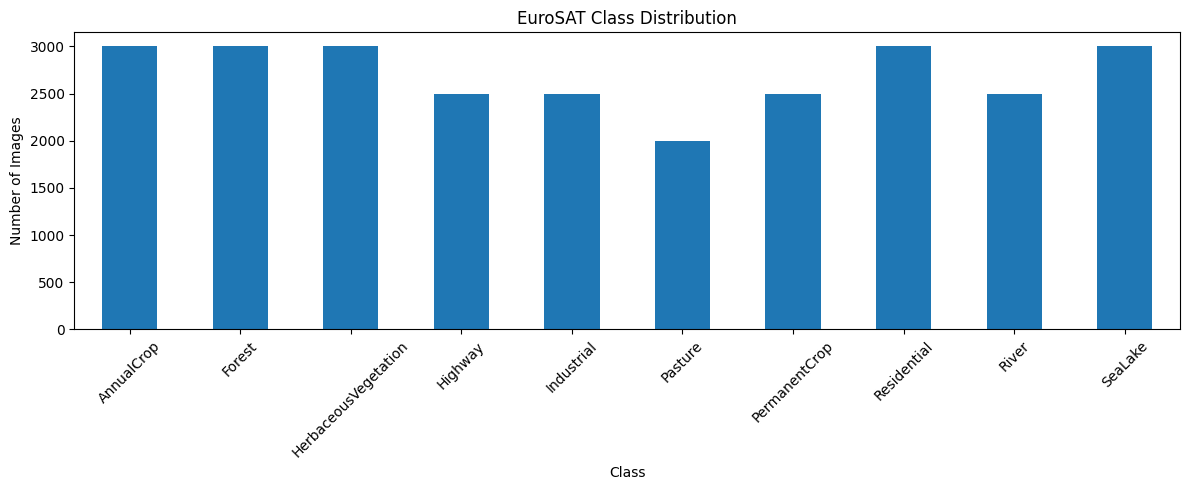

In [19]:
plt.figure(figsize=(12, 5))
class_counts.plot(kind="bar")
plt.title("EuroSAT Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

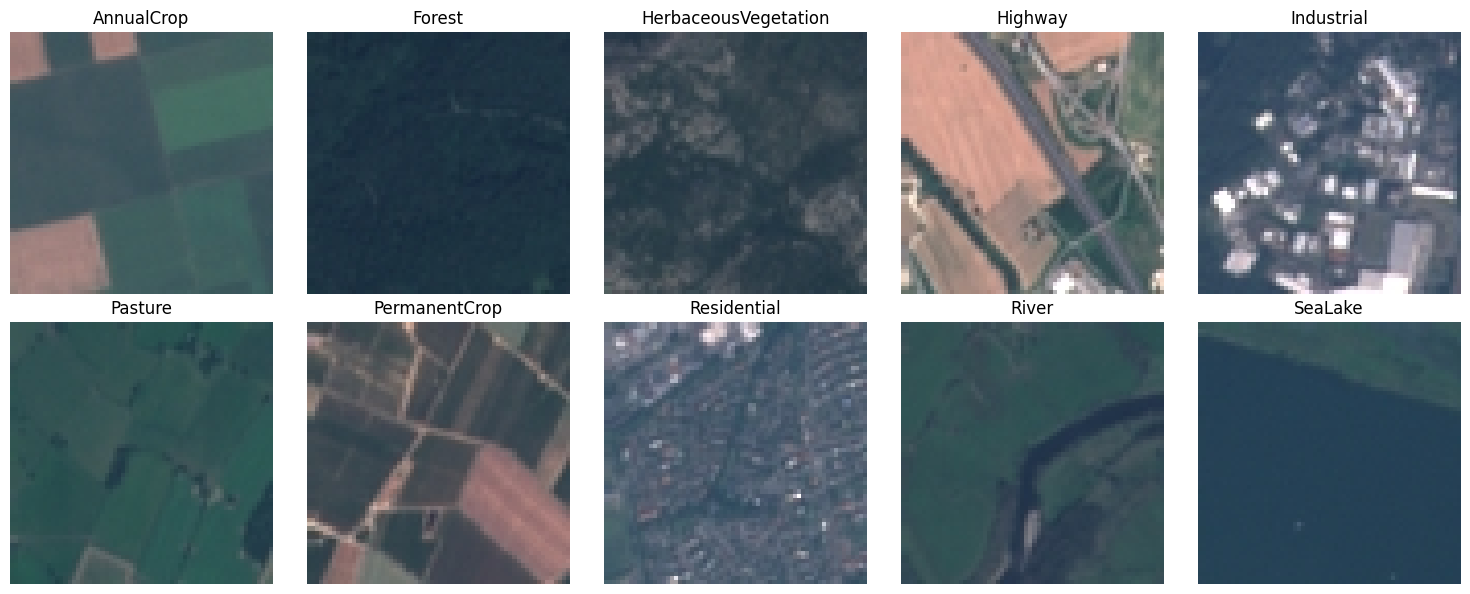

In [20]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for ax, class_name in zip(axes, class_names):
    sample_path = df[df["label"] == class_name]["filepath"].sample(1, random_state=SEED).iloc[0]
    img = Image.open(sample_path)
    ax.imshow(img)
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

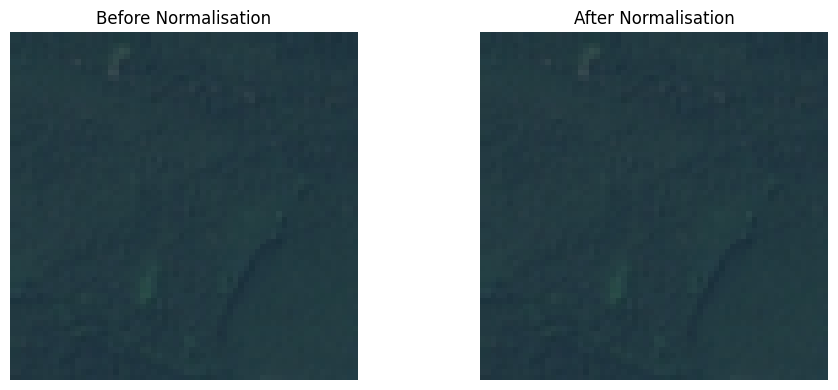

Original range: 24 to 79
Normalised range: 0.09411764705882353 to 0.30980392156862746


In [22]:
sample_path = df["filepath"].sample(1, random_state=SEED).iloc[0]
img = Image.open(sample_path).convert("RGB")
img_array = np.array(img)

img_normalized = img_array / 255.0

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(img_array)
axes[0].set_title("Before Normalisation")
axes[0].axis("off")

axes[1].imshow(img_normalized)
axes[1].set_title("After Normalisation")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Original range:", img_array.min(), "to", img_array.max())
print("Normalised range:", img_normalized.min(), "to", img_normalized.max())

In [23]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 18900
Validation size: 4050
Test size: 4050


In [24]:
split_counts = pd.DataFrame({
    "train": train_df["label"].value_counts().sort_index(),
    "val": val_df["label"].value_counts().sort_index(),
    "test": test_df["label"].value_counts().sort_index()
})

split_counts

,train,val,test
label,,,
AnnualCrop,2100,450,450
Forest,2100,450,450
HerbaceousVegetation,2100,450,450
Highway,1750,375,375
Industrial,1750,375,375
Pasture,1400,300,300
PermanentCrop,1750,375,375
Residential,2100,450,450
River,1750,375,375


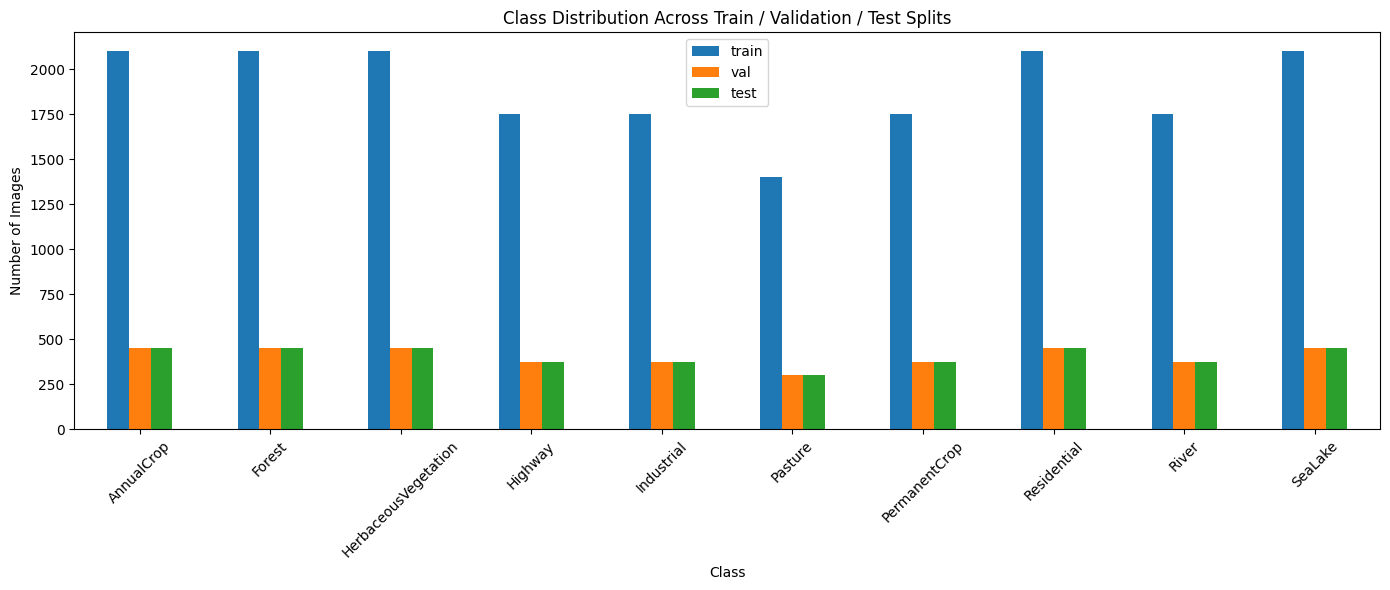

In [25]:
split_counts.plot(kind="bar", figsize=(14, 6))
plt.title("Class Distribution Across Train / Validation / Test Splits")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
split_dir = Path("../Data/Splits")
split_dir.mkdir(parents=True, exist_ok=True)

train_df.to_csv(split_dir / "train.csv", index=False)
val_df.to_csv(split_dir / "val.csv", index=False)
test_df.to_csv(split_dir / "test.csv", index=False)

print("Saved split CSV files to:", split_dir.resolve())

Saved split CSV files to: C:\Users\PC\Desktop\SpaceLandMapper\Data\Splits


In [28]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

In [29]:
tf.random.set_seed(SEED)
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [30]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

In [31]:
train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_gen = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 18900 validated image filenames belonging to 10 classes.
Found 4050 validated image filenames belonging to 10 classes.
Found 4050 validated image filenames belonging to 10 classes.


In [32]:
baseline_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

baseline_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,250 (42.61 MB)

 Trainable params: 11,170,250 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [34]:
history_baseline = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 513s 865ms/step - accuracy: 0.5052 - loss: 1.3571 - val_accuracy: 0.6160 - val_loss: 1.0121
Epoch 2/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 354s 598ms/step - accuracy: 0.6650 - loss: 0.9391 - val_accuracy: 0.6854 - val_loss: 0.8729
Epoch 3/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 383s 648ms/step - accuracy: 0.7156 - loss: 0.8122 - val_accuracy: 0.7783 - val_loss: 0.6194
Epoch 4/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 357s 604ms/step - accuracy: 0.7586 - loss: 0.6833 - val_accuracy: 0.7741 - val_loss: 0.6292
Epoch 5/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 354s 599ms/step - accuracy: 0.7813 - loss: 0.6350 - val_accuracy: 0.7402 - val_loss: 0.7497
Epoch 6/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 339s 574ms/step - accuracy: 0.7932 - loss: 0.5914 - val_accuracy: 0.8272 - val_loss: 0.4898
Epoch 7/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 342s 579ms/step - accuracy: 0.8100 - loss: 0.5486 - val_accuracy: 0.8410 - val_loss: 0.4643
Epoch 8/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 337s 571ms/step - accuracy: 0.8287 -

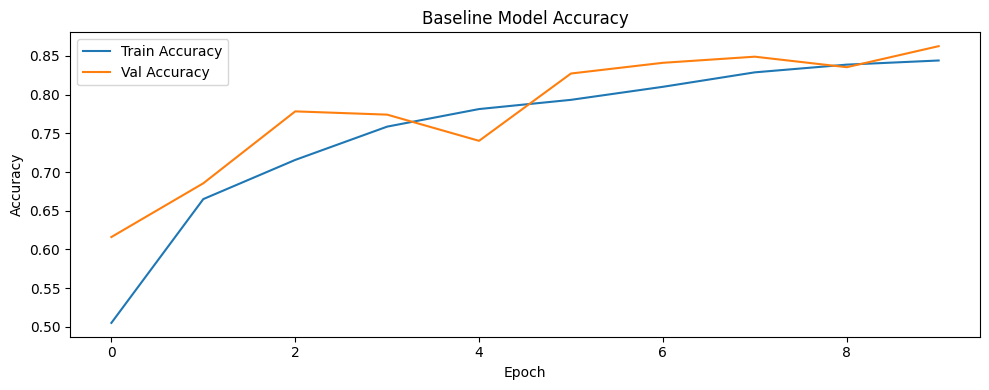

In [35]:
plt.figure(figsize=(10, 4))
plt.plot(history_baseline.history["accuracy"], label="Train Accuracy")
plt.plot(history_baseline.history["val_accuracy"], label="Val Accuracy")
plt.title("Baseline Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

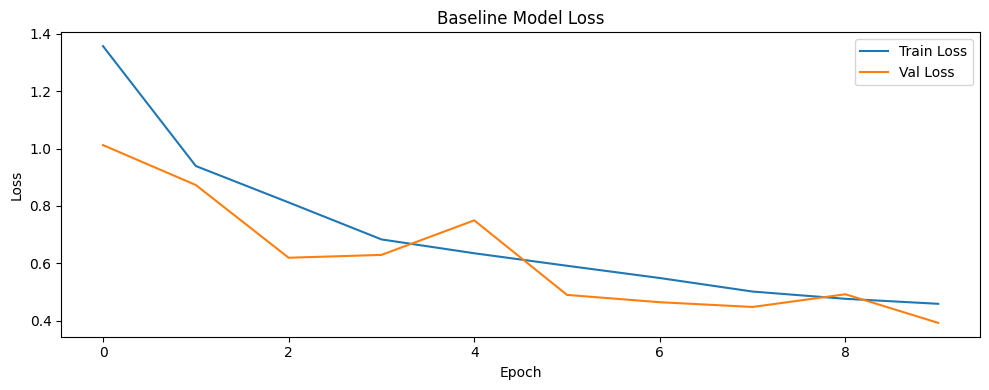

In [36]:
plt.figure(figsize=(10, 4))
plt.plot(history_baseline.history["loss"], label="Train Loss")
plt.plot(history_baseline.history["val_loss"], label="Val Loss")
plt.title("Baseline Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
test_loss, test_acc = baseline_model.evaluate(test_gen)
print("Baseline Test Accuracy:", test_acc)

127/127 ━━━━━━━━━━━━━━━━━━━━ 34s 270ms/step - accuracy: 0.8733 - loss: 0.3709
Baseline Test Accuracy: 0.8733333349227905


In [38]:
model_dir = Path("../Outputs/Models")
model_dir.mkdir(parents=True, exist_ok=True)

baseline_model.save(model_dir / "baseline_cnn.keras")
print("Baseline model saved to:", model_dir.resolve())

Baseline model saved to: C:\Users\PC\Desktop\SpaceLandMapper\Outputs\Models


In [39]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

In [40]:
train_datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [41]:
train_gen_eff = train_datagen_eff.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_gen_eff = val_test_datagen_eff.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_gen_eff = val_test_datagen_eff.flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 18900 validated image filenames belonging to 10 classes.
Found 4050 validated image filenames belonging to 10 classes.
Found 4050 validated image filenames belonging to 10 classes.


In [42]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(10, activation="softmax")(x)

eff_model = Model(inputs, outputs)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [43]:
eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

eff_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,380,077 (16.71 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [44]:
checkpoint_dir = Path("../Outputs/Models")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6
    ),
    ModelCheckpoint(
        filepath=checkpoint_dir / "efficientnet_frozen_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [45]:
history_eff_frozen = eff_model.fit(
    train_gen_eff,
    validation_data=val_gen_eff,
    epochs=5,
    steps_per_epoch=150,
    validation_steps=50,
    callbacks=callbacks
)

Epoch 1/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 128s 795ms/step - accuracy: 0.7812 - loss: 0.6697 - val_accuracy: 0.8462 - val_loss: 0.4864 - learning_rate: 0.0010
Epoch 2/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 109s 727ms/step - accuracy: 0.8840 - loss: 0.3479 - val_accuracy: 0.8706 - val_loss: 0.3919 - learning_rate: 0.0010
Epoch 3/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 114s 760ms/step - accuracy: 0.8854 - loss: 0.3421 - val_accuracy: 0.8587 - val_loss: 0.3933 - learning_rate: 0.0010
Epoch 4/5
141/150 ━━━━━━━━━━━━━━━━━━━━ 5s 614ms/step - accuracy: 0.8921 - loss: 0.3045

c:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


150/150 ━━━━━━━━━━━━━━━━━━━━ 112s 747ms/step - accuracy: 0.8871 - loss: 0.3223 - val_accuracy: 0.8863 - val_loss: 0.3383 - learning_rate: 0.0010
Epoch 5/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 117s 782ms/step - accuracy: 0.9019 - loss: 0.2793 - val_accuracy: 0.8894 - val_loss: 0.3345 - learning_rate: 0.0010


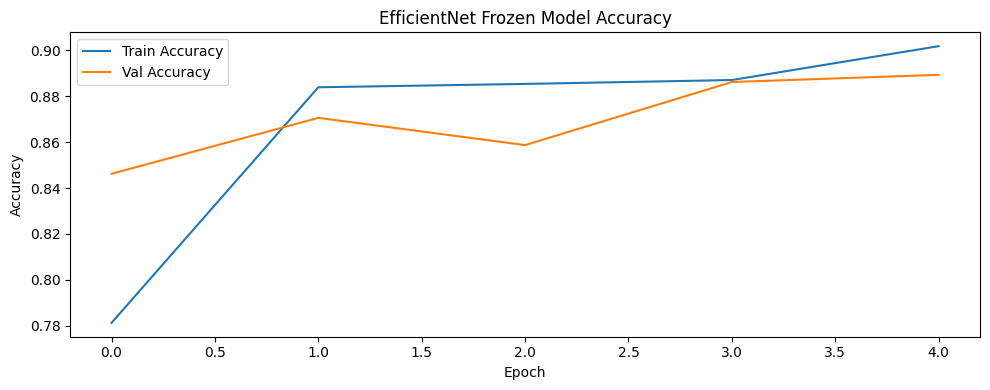

In [46]:
plt.figure(figsize=(10, 4))
plt.plot(history_eff_frozen.history["accuracy"], label="Train Accuracy")
plt.plot(history_eff_frozen.history["val_accuracy"], label="Val Accuracy")
plt.title("EfficientNet Frozen Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

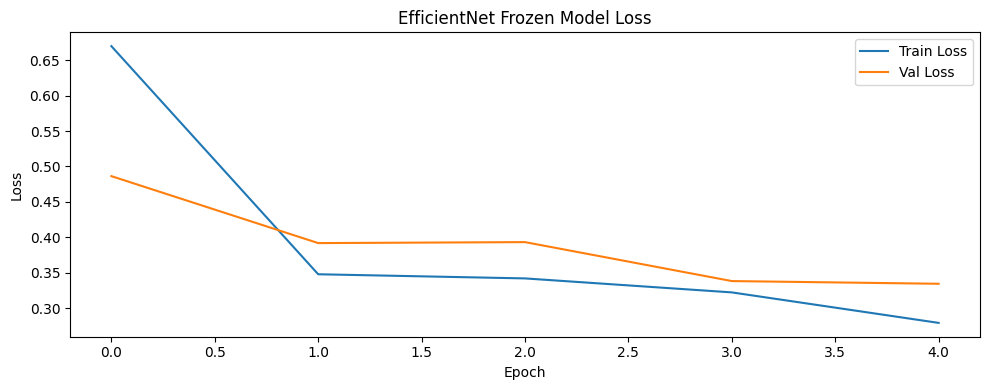

In [47]:
plt.figure(figsize=(10, 4))
plt.plot(history_eff_frozen.history["loss"], label="Train Loss")
plt.plot(history_eff_frozen.history["val_loss"], label="Val Loss")
plt.title("EfficientNet Frozen Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [48]:
test_gen_eff.reset()
test_loss_eff, test_acc_eff = eff_model.evaluate(test_gen_eff)
print("EfficientNet Frozen Test Accuracy:", test_acc_eff)

127/127 ━━━━━━━━━━━━━━━━━━━━ 61s 479ms/step - accuracy: 0.8995 - loss: 0.2944
EfficientNet Frozen Test Accuracy: 0.899506151676178


In [49]:
print("Baseline Test Accuracy:", test_acc)
print("EfficientNet Frozen Test Accuracy:", test_acc_eff)

Baseline Test Accuracy: 0.8733333349227905
EfficientNet Frozen Test Accuracy: 0.899506151676178


In [50]:
base_model.trainable = True

# Freeze the earlier layers, unfreeze only the top layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

for layer in base_model.layers[-20:]:
    layer.trainable = True

print("Trainable layers in base model:", sum([layer.trainable for layer in base_model.layers]))

Trainable layers in base model: 20


In [51]:
eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [52]:
fine_tune_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    ),
    ModelCheckpoint(
        filepath=checkpoint_dir / "efficientnet_finetuned_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [53]:
history_eff_finetune = eff_model.fit(
    train_gen_eff,
    validation_data=val_gen_eff,
    epochs=5,
    steps_per_epoch=150,
    validation_steps=50,
    callbacks=fine_tune_callbacks
)

Epoch 1/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 130s 809ms/step - accuracy: 0.8010 - loss: 0.6134 - val_accuracy: 0.8775 - val_loss: 0.3615 - learning_rate: 1.0000e-05
Epoch 2/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 118s 785ms/step - accuracy: 0.8440 - loss: 0.4814 - val_accuracy: 0.8656 - val_loss: 0.4003 - learning_rate: 1.0000e-05
Epoch 3/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 118s 787ms/step - accuracy: 0.8679 - loss: 0.4110 - val_accuracy: 0.8631 - val_loss: 0.4010 - learning_rate: 1.0000e-05
Epoch 4/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 110s 735ms/step - accuracy: 0.8731 - loss: 0.3879 - val_accuracy: 0.8619 - val_loss: 0.4022 - learning_rate: 2.0000e-06


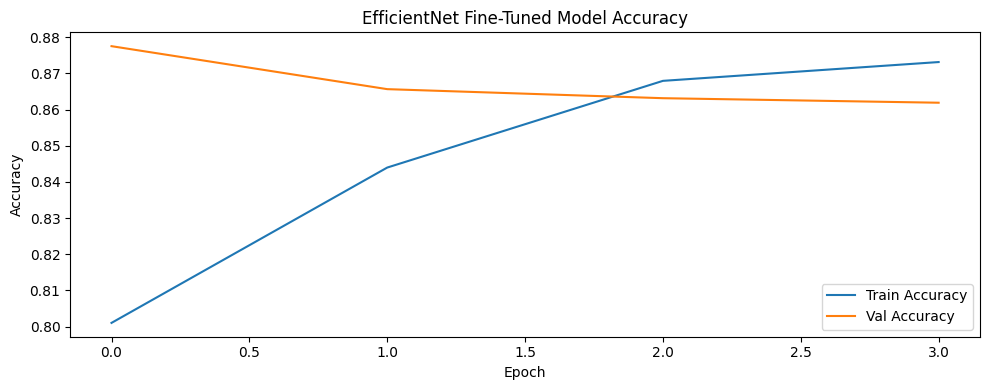

In [54]:
plt.figure(figsize=(10, 4))
plt.plot(history_eff_finetune.history["accuracy"], label="Train Accuracy")
plt.plot(history_eff_finetune.history["val_accuracy"], label="Val Accuracy")
plt.title("EfficientNet Fine-Tuned Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

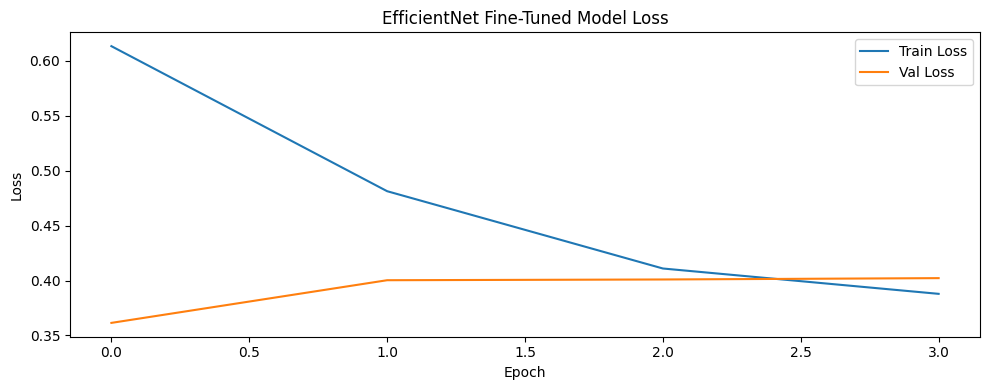

In [55]:
plt.figure(figsize=(10, 4))
plt.plot(history_eff_finetune.history["loss"], label="Train Loss")
plt.plot(history_eff_finetune.history["val_loss"], label="Val Loss")
plt.title("EfficientNet Fine-Tuned Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [56]:
test_gen_eff.reset()
test_loss_eff_ft, test_acc_eff_ft = eff_model.evaluate(test_gen_eff)
print("EfficientNet Fine-Tuned Test Accuracy:", test_acc_eff_ft)

127/127 ━━━━━━━━━━━━━━━━━━━━ 58s 458ms/step - accuracy: 0.8909 - loss: 0.3319
EfficientNet Fine-Tuned Test Accuracy: 0.8908641934394836


In [57]:
print("Baseline Test Accuracy:", test_acc)
print("EfficientNet Frozen Test Accuracy:", test_acc_eff)
print("EfficientNet Fine-Tuned Test Accuracy:", test_acc_eff_ft)

Baseline Test Accuracy: 0.8733333349227905
EfficientNet Frozen Test Accuracy: 0.899506151676178
EfficientNet Fine-Tuned Test Accuracy: 0.8908641934394836


In [58]:
final_model_path = checkpoint_dir / "efficientnet_finetuned_best.keras"
print("Final best model saved at:", final_model_path.resolve())

Final best model saved at: C:\Users\PC\Desktop\SpaceLandMapper\Outputs\Models\efficientnet_finetuned_best.keras


In [59]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [60]:
test_gen_eff.reset()
pred_probs = eff_model.predict(test_gen_eff)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_gen_eff.classes
class_labels = list(test_gen_eff.class_indices.keys())

127/127 ━━━━━━━━━━━━━━━━━━━━ 63s 484ms/step


In [61]:
report = classification_report(
    true_classes,
    pred_classes,
    target_names=class_labels
)

print(report)

                      precision    recall  f1-score   support

          AnnualCrop       0.87      0.93      0.90       450
              Forest       0.96      0.97      0.96       450
HerbaceousVegetation       0.77      0.91      0.83       450
             Highway       0.80      0.89      0.84       375
          Industrial       0.90      0.90      0.90       375
             Pasture       0.99      0.73      0.84       300
       PermanentCrop       0.88      0.73      0.80       375
         Residential       0.94      0.94      0.94       450
               River       0.87      0.88      0.87       375
             SeaLake       1.00      0.95      0.97       450

            accuracy                           0.89      4050
           macro avg       0.90      0.88      0.89      4050
        weighted avg       0.90      0.89      0.89      4050



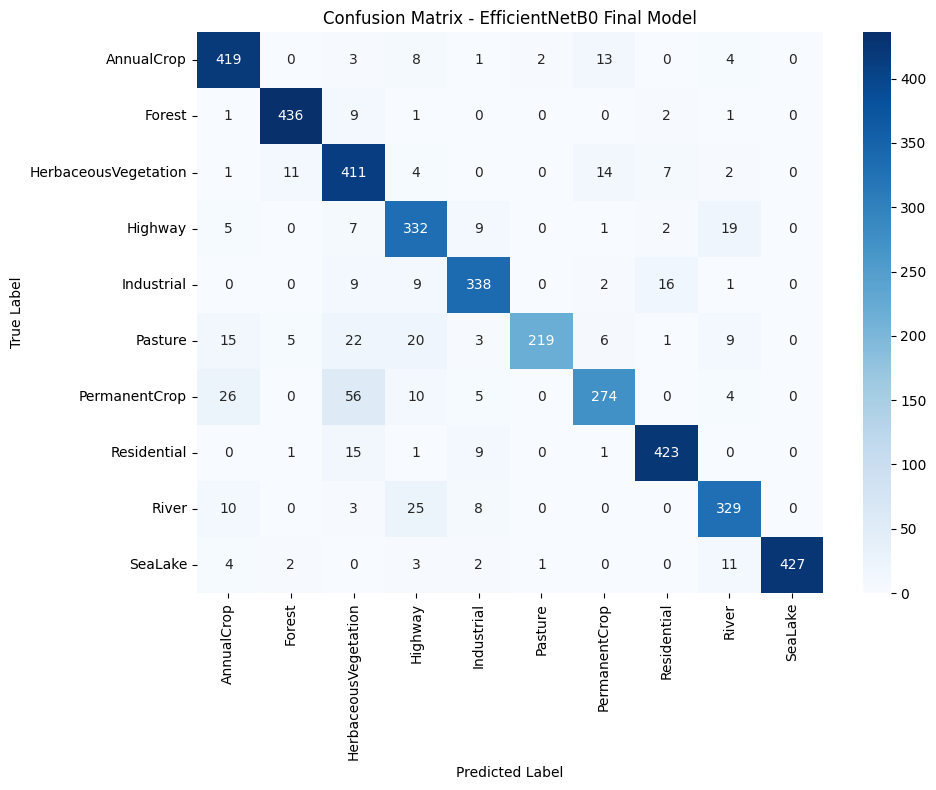

In [62]:
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - EfficientNetB0 Final Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

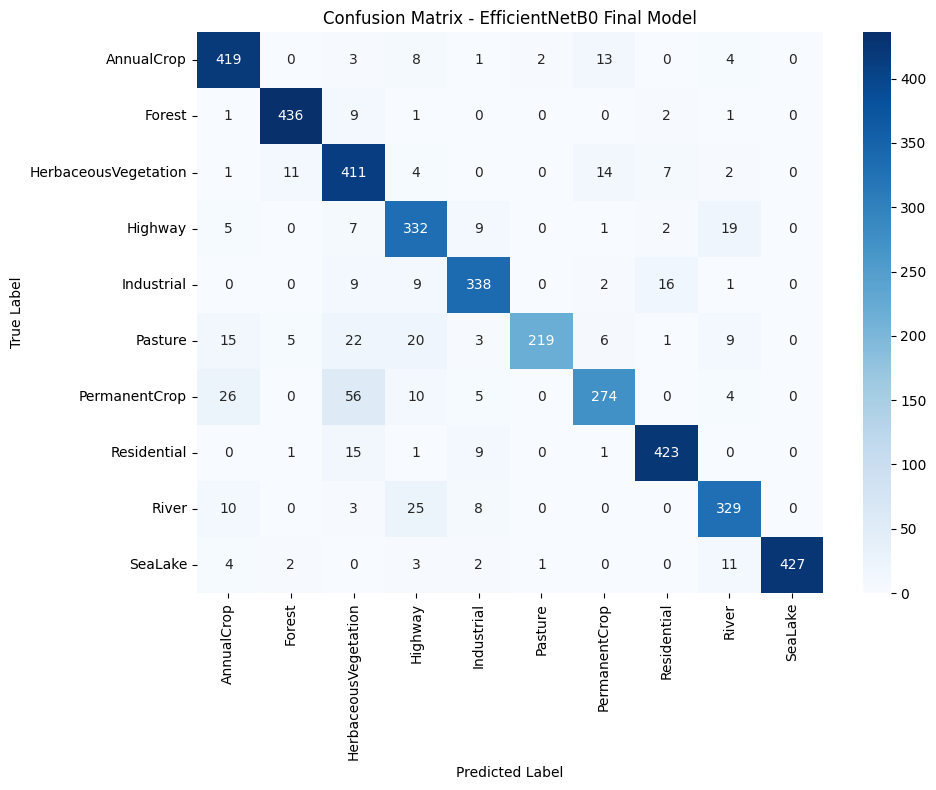

Confusion matrix saved to: C:\Users\PC\Desktop\SpaceLandMapper\Outputs\Figures


In [63]:
fig_dir = Path("../Outputs/Figures")
fig_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - EfficientNetB0 Final Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(fig_dir / "confusion_matrix_efficientnet_final.png", dpi=300)
plt.show()

print("Confusion matrix saved to:", fig_dir.resolve())

In [64]:
final_model = tf.keras.models.load_model("../Outputs/Models/efficientnet_frozen_best.keras")
print("Final model loaded.")

Final model loaded.


In [65]:
from tensorflow.keras.preprocessing import image

def predict_image(img_path, model, class_labels):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)
    pred_class = class_labels[np.argmax(preds)]
    confidence = np.max(preds)

    plt.imshow(img)
    plt.title(f"Predicted: {pred_class} ({confidence:.2f})")
    plt.axis("off")
    plt.show()

    return pred_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


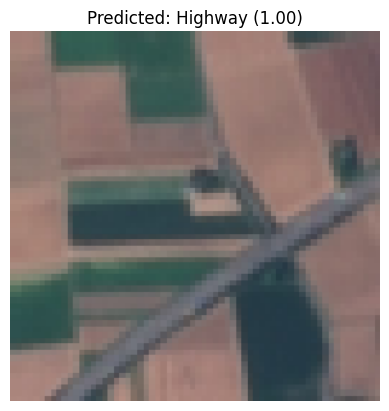

('Highway', 0.99782014)

In [76]:
sample_img = test_df="../Data/Raw/EuroSAT_RGB/Highway/Highway_15.jpg"

predict_image(sample_img, final_model, class_labels)

In [77]:
from PIL import Image, ImageDraw
from collections import Counter

In [78]:
class_color_map = {
    "AnnualCrop": (255, 215, 0),          # yellow
    "Forest": (34, 139, 34),              # green
    "HerbaceousVegetation": (144, 238, 144),  # light green
    "Highway": (128, 128, 128),           # gray
    "Industrial": (105, 105, 105),        # dark gray
    "Pasture": (189, 183, 107),           # khaki
    "PermanentCrop": (218, 165, 32),      # golden brown
    "Residential": (220, 20, 60),         # red
    "River": (30, 144, 255),              # blue
    "SeaLake": (0, 0, 139)                # dark blue
}

In [79]:
from tensorflow.keras.preprocessing import image

def predict_tile(tile_img, model, class_labels):
    tile_img = tile_img.resize((224, 224))
    tile_array = image.img_to_array(tile_img)
    tile_array = preprocess_input(tile_array)
    tile_array = np.expand_dims(tile_array, axis=0)

    preds = model.predict(tile_array, verbose=0)
    pred_class = class_labels[np.argmax(preds)]
    confidence = float(np.max(preds))

    return pred_class, confidence

In [80]:
def classify_image_in_grid(img_path, model, class_labels, tile_size=64):
    img = Image.open(img_path).convert("RGB")
    width, height = img.size

    grid_predictions = []
    tile_details = []

    for y in range(0, height, tile_size):
        row_predictions = []
        for x in range(0, width, tile_size):
            tile = img.crop((x, y, min(x + tile_size, width), min(y + tile_size, height)))
            pred_class, confidence = predict_tile(tile, model, class_labels)

            row_predictions.append(pred_class)

            tile_details.append({
                "x": x,
                "y": y,
                "predicted_class": pred_class,
                "confidence": confidence
            })

        grid_predictions.append(row_predictions)

    return img, grid_predictions, tile_details

In [81]:
def create_color_grid_map(original_img, tile_details, class_color_map, tile_size=64):
    width, height = original_img.size
    color_map_img = Image.new("RGB", (width, height), (255, 255, 255))
    draw = ImageDraw.Draw(color_map_img)

    for tile in tile_details:
        x = tile["x"]
        y = tile["y"]
        pred_class = tile["predicted_class"]
        color = class_color_map.get(pred_class, (0, 0, 0))

        draw.rectangle(
            [x, y, min(x + tile_size, width), min(y + tile_size, height)],
            fill=color
        )

    return color_map_img

In [88]:
def calculate_class_percentages(tile_details):
    predicted_classes = [tile["predicted_class"] for tile in tile_details]
    counts = Counter(predicted_classes)
    total = sum(counts.values())

    percentages = {
        cls: round((count / total) * 100, 2)
        for cls, count in counts.items()
    }

    return counts, percentages

In [92]:
print("Type of test_df:", type(test_df))
print(test_df)

Type of test_df: <class 'str'>
../Data/Raw/EuroSAT_RGB/Highway/Highway_15.jpg


In [93]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

In [94]:
grid_img_path = test_df["filepath"].iloc[0]
print(grid_img_path)

..\Data\Raw\EuroSAT_RGB\PermanentCrop\PermanentCrop_1526.jpg


In [95]:
original_img, grid_predictions, tile_details = classify_image_in_grid(
    grid_img_path,
    final_model,
    class_labels,
    tile_size=64
)

print("original_img type:", type(original_img))
print("grid_predictions type:", type(grid_predictions))
print("tile_details type:", type(tile_details))
print("First tile detail:", tile_details[0])

original_img type: <class 'PIL.Image.Image'>
grid_predictions type: <class 'list'>
tile_details type: <class 'list'>
First tile detail: {'x': 0, 'y': 0, 'predicted_class': 'PermanentCrop', 'confidence': 0.9345036745071411}


In [96]:
color_map_img = create_color_grid_map(
    original_img,
    tile_details,
    class_color_map,
    tile_size=64
)

print("color_map_img type:", type(color_map_img))

color_map_img type: <class 'PIL.Image.Image'>


In [98]:
counts, percentages = calculate_class_percentages(tile_details)

print("Tile counts:", counts)
print("Class percentages:", percentages)

Tile counts: Counter({'PermanentCrop': 1})
Class percentages: {'PermanentCrop': 100.0}


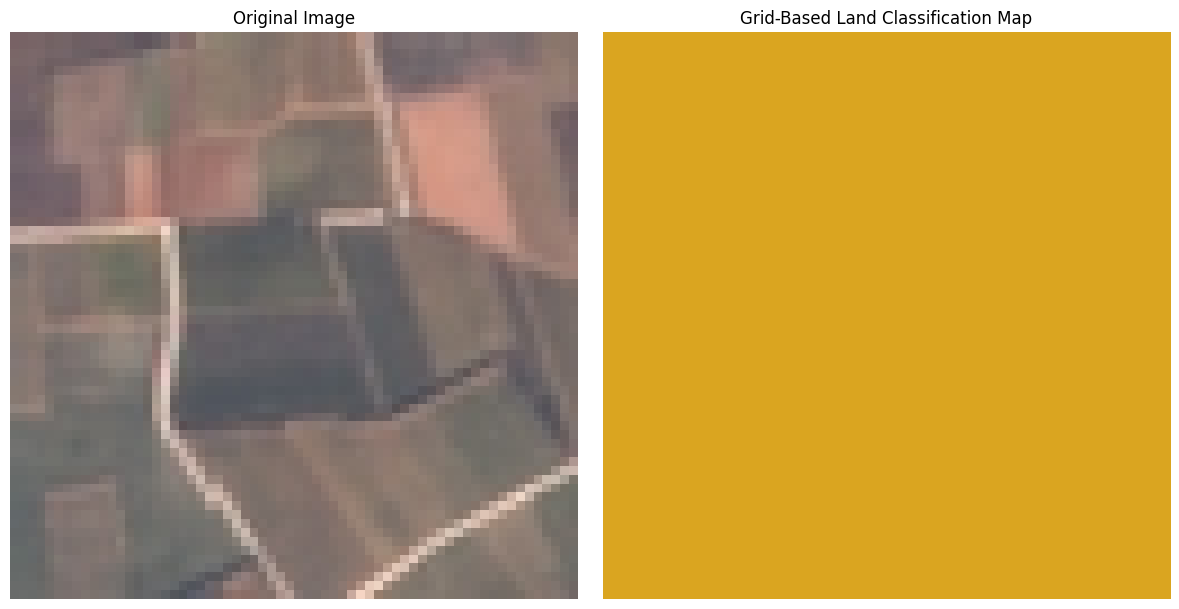

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(original_img)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(color_map_img)
axes[1].set_title("Grid-Based Land Classification Map")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [100]:
percentages_sorted = dict(sorted(percentages.items(), key=lambda x: x[1], reverse=True))

for cls, pct in percentages_sorted.items():
    print(f"{cls}: {pct}%")

PermanentCrop: 100.0%


In [101]:
custom_img_path = "../Data/TestImages/TestImage.png"

original_img, grid_predictions, tile_details = classify_image_in_grid(
    custom_img_path,
    final_model,
    class_labels,
    tile_size=64
)

color_map_img = create_color_grid_map(
    original_img,
    tile_details,
    class_color_map,
    tile_size=64
)

counts, percentages = calculate_class_percentages(tile_details)

print("Tile counts:", counts)
print("Class percentages:", percentages)

Tile counts: Counter({'SeaLake': 33, 'Residential': 30, 'Highway': 11, 'Forest': 10, 'River': 4, 'Industrial': 2})
Class percentages: {'SeaLake': 36.67, 'Forest': 11.11, 'Residential': 33.33, 'River': 4.44, 'Highway': 12.22, 'Industrial': 2.22}


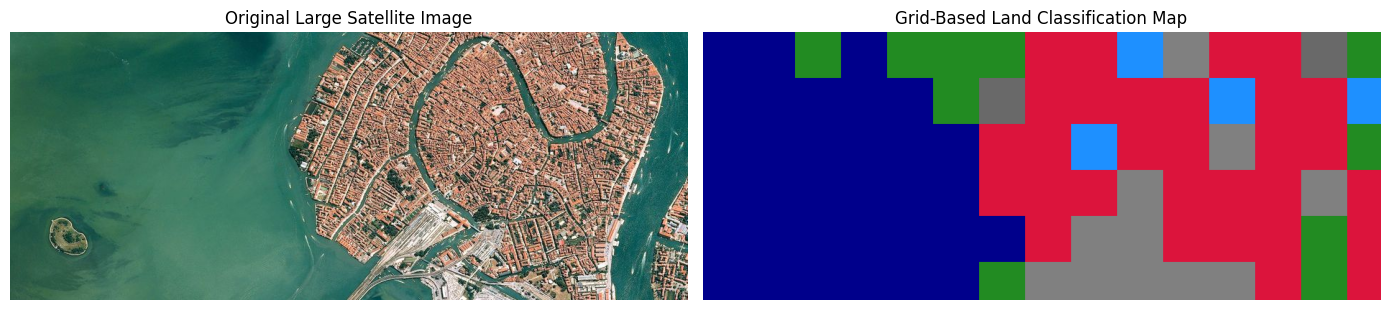

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(original_img)
axes[0].set_title("Original Large Satellite Image")
axes[0].axis("off")

axes[1].imshow(color_map_img)
axes[1].set_title("Grid-Based Land Classification Map")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [103]:
percentages_sorted = dict(sorted(percentages.items(), key=lambda x: x[1], reverse=True))

for cls, pct in percentages_sorted.items():
    print(f"{cls}: {pct}%")

SeaLake: 36.67%
Residential: 33.33%
Highway: 12.22%
Forest: 11.11%
River: 4.44%
Industrial: 2.22%


In [105]:
output_dir = Path("../Outputs/Figures")
output_dir.mkdir(parents=True, exist_ok=True)

color_map_img.save(output_dir / "grid_land_classification_map.png")
print("Saved map to:", (output_dir / "grid_land_classification_map.png").resolve())

Saved map to: C:\Users\PC\Desktop\SpaceLandMapper\Outputs\Figures\grid_land_classification_map.png
